# 배경제거 테스트

In [4]:
#timm kornia einops torch transformers
# Load BiRefNet with weights
from transformers import AutoModelForImageSegmentation
birefnet = AutoModelForImageSegmentation.from_pretrained('ZhengPeng7/BiRefNet', trust_remote_code=True)

from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

torch.set_float32_matmul_precision(['high', 'highest'][0])
birefnet.to('cuda')
birefnet.eval()
birefnet.half()

BiRefNet(
  (bb): SwinTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
      (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (layers): ModuleList(
      (0): BasicLayer(
        (blocks): ModuleList(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
            (attn): WindowAttention(
              (qkv): Linear(in_features=192, out_features=576, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=192, out_features=192, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
              (softmax): Softmax(dim=-1)
            )
            (drop_path): Identity()
            (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=192, out_features=768, bias=T

In [5]:
def extract_mask_only(birefnet, imagepath):
    # Data settings
    image_size = (1024, 1024)
    transform_image = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    image = Image.open(imagepath)
    input_images = transform_image(image).unsqueeze(0).to('cuda').half()

    # Prediction
    with torch.no_grad():
        preds = birefnet(input_images)[-1].sigmoid().cpu()
    pred = preds[0].squeeze()
    pred_pil = transforms.ToPILImage()(pred)
    mask = pred_pil.resize(image.size)
    
    return mask  # 마스크만 반환


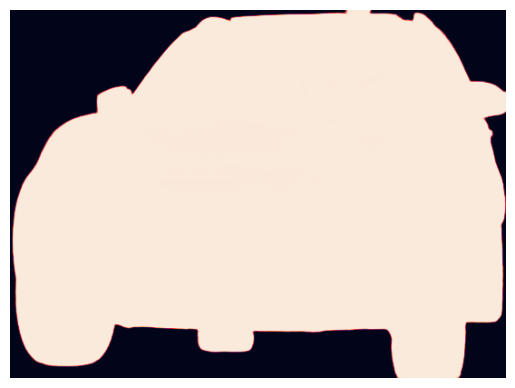

In [8]:
mask = extract_mask_only(birefnet, imagepath=r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\train\디스커버리_5_2017_2020\디스커버리_5_2017_2020_0001.jpg")
plt.axis("off")
plt.imshow(extract_mask_only(birefnet, imagepath=r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\train\디스커버리_5_2017_2020\디스커버리_5_2017_2020_0001.jpg"))
plt.show()

## inpainting 증강

In [6]:
from PIL import Image, ImageOps

def resize_with_padding(img, target_size=(768, 768), fill=0):
    """
    이미지 비율 유지 + 원하는 사이즈에 맞춰 패딩 추가
    :param img: PIL 이미지
    :param target_size: (width, height)
    :return: (패딩된 이미지, 패딩 위치, 리사이즈된 크기)
    """
    img = img.convert("RGB") if img.mode != "RGB" else img

    target_w, target_h = target_size
    orig_w, orig_h = img.size

    ratio = min(target_w / orig_w, target_h / orig_h)
    new_w = int(orig_w * ratio)
    new_h = int(orig_h * ratio)

    resized = img.resize((new_w, new_h), Image.LANCZOS)

    new_img = Image.new("RGB", (target_w, target_h), (fill, fill, fill))
    paste_pos = ((target_w - new_w) // 2, (target_h - new_h) // 2)
    new_img.paste(resized, paste_pos)

    return new_img, paste_pos, (new_w, new_h)


In [7]:
def remove_padding_and_resize(result_img, paste_pos, resized_size, original_size):
    """
    인페인팅 후, 패딩 제거 및 원본 해상도로 복원
    """
    cropped = result_img.crop((
        paste_pos[0],
        paste_pos[1],
        paste_pos[0] + resized_size[0],
        paste_pos[1] + resized_size[1],
    ))
    return cropped.resize(original_size, Image.LANCZOS)


In [9]:
from diffusers import StableDiffusionInpaintPipeline
from PIL import Image, ImageOps
import torch

# 1. 로딩
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2-inpainting",
    torch_dtype=torch.float16,
)
pipe.to("cuda")

# 2. 이미지 & 마스크 로드
image = Image.open(r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\train\1시리즈_F20_2016_2019\1시리즈_F20_2016_2019_0000.jpg").convert("RGB")
mask = Image.open(r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\extracted_mask\1시리즈_F20_2016_2019\1시리즈_F20_2016_2019_0000_mask.png").convert("L")
mask = ImageOps.invert(mask)  # 마스크 반전

# 3. 전처리 (원하는 사이즈로 패딩 포함 리사이즈)
target_size = (768, 768)
resized_image, pos, size = resize_with_padding(image, target_size)
resized_mask, _, _ = resize_with_padding(mask.convert("RGB"), target_size)

# 4. 인페인팅
prompt = "Car showroom with shiny sports cars and glass walls"
result = pipe(prompt=prompt, image=resized_image, mask_image=resized_mask).images[0]

# 5. 복원
final = remove_padding_and_resize(result, pos, size, image.size)
final.save("./inpainting_car_showroom_restored.png")


100%|██████████| 50/50 [00:03<00:00, 13.14it/s]


# 파일 통계

In [4]:
import os

# 상위 디렉토리 경로
base_dir = r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\train"

# 결과 저장용 리스트
stats = []

# 하위 디렉토리 순회
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)
    if os.path.isdir(class_path):
        # 파일 개수 세기 (하위 폴더 무시)
        num_files = len([
            f for f in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, f))
        ])
        stats.append((class_name, num_files))

# 정렬 (파일 수 기준 내림차순)
stats.sort(key=lambda x: x[1], reverse=True)

# 출력
print(f"총 클래스 수: {len(stats)}\n")
print(f"{'클래스명':<50} | 파일 수")
print("-" * 65)
for cls, count in stats:
    print(f"{cls:<50} | {count}")


총 클래스 수: 396

클래스명                                               | 파일 수
-----------------------------------------------------------------
프리우스_4세대_2019_2022                                 | 90
3시리즈_E90_2005_2012                                 | 88
3시리즈_F30_2013_2018                                 | 88
3시리즈_GT_F34_2014_2021                              | 88
4시리즈_F32_2014_2020                                 | 88
7시리즈_G11_2019_2022                                 | 88
A5_F5_2019_2024                                    | 88
All_New_XJ_2016_2019                               | 88
B_클래스_W246_2013_2018                               | 88
CLA_클래스_C117_2014_2019                             | 88
CLA_클래스_C118_2020_2025                             | 88
CLS_클래스_C257_2019_2023                             | 88
EV6_2022_2024                                      | 88
EV9_2024_2025                                      | 88
G80_RG3_2025                                       | 88
GLC_클래스_X253_2017_2019

# post preprocessing


In [5]:
from tqdm import tqdm

# 디렉토리 설정
src_root = r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\train"
dst_root = r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\extracted_mask"


In [6]:
# 마스크 저장 루프 수정
for class_name in tqdm(os.listdir(src_root), desc="클래스 처리"):
    src_class_path = os.path.join(src_root, class_name)
    dst_class_path = os.path.join(dst_root, class_name)
    
    if not os.path.isdir(src_class_path):
        continue

    # 수정된 부분: 중간 폴더까지 생성
    os.makedirs(dst_class_path, exist_ok=True)

    for fname in os.listdir(src_class_path):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        src_img_path = os.path.join(src_class_path, fname)
        mask_name = os.path.splitext(fname)[0] + "_mask.png"
        mask_path = os.path.join(dst_class_path, mask_name)

        if os.path.exists(mask_path):
            continue

        try:
            mask = extract_mask_only(birefnet, src_img_path)
            mask.save(mask_path)
        except Exception as e:
            print(f"Error processing {fname}: {e}")

클래스 처리: 100%|██████████| 396/396 [2:19:16<00:00, 21.10s/it]  


In [9]:
import os

# 경로 설정
src_root = r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\train"
dst_root = r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\rm_bg_train"

# 원본 및 처리 후 클래스 목록 가져오기
src_classes = set([d for d in os.listdir(src_root) if os.path.isdir(os.path.join(src_root, d))])
dst_classes = set([d for d in os.listdir(dst_root) if os.path.isdir(os.path.join(dst_root, d))])

# 클래스 수 비교
print(f"원본 클래스 수: {len(src_classes)}")
print(f"배경제거 후 클래스 수: {len(dst_classes)}")

# 누락된 클래스 찾기
missing_classes = src_classes - dst_classes
if missing_classes:
    print("\n누락된 클래스:")
    for cls in missing_classes:
        src_class_path = os.path.join(src_root, cls)
        file_count = len([f for f in os.listdir(src_class_path) 
                         if os.path.isfile(os.path.join(src_class_path, f)) 
                         and f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f"- {cls}: 원본 파일 {file_count}개")

# 원본에는 없지만 처리 후에 있는 클래스 찾기
extra_classes = dst_classes - src_classes
if extra_classes:
    print("\n추가된 클래스(원본에는 없음):")
    for cls in extra_classes:
        print(f"- {cls}")

# 클래스는 생성되었지만 비어있는 디렉토리 확인
empty_dst_dirs = []
for cls in dst_classes:
    dst_class_path = os.path.join(dst_root, cls)
    if len(os.listdir(dst_class_path)) == 0:
        empty_dst_dirs.append(cls)

if empty_dst_dirs:
    print("\n빈 디렉토리(처리 후):")
    for cls in empty_dst_dirs:
        print(f"- {cls}")

# 파일 수가 다른 클래스 확인
print("\n파일 수 차이가 있는 클래스:")
for cls in src_classes.intersection(dst_classes):  # 공통 클래스만 확인
    src_class_path = os.path.join(src_root, cls)
    dst_class_path = os.path.join(dst_root, cls)
    
    src_files = len([f for f in os.listdir(src_class_path) 
                     if os.path.isfile(os.path.join(src_class_path, f)) 
                     and f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    dst_files = len([f for f in os.listdir(dst_class_path) 
                     if os.path.isfile(os.path.join(dst_class_path, f))])
    
    if src_files != dst_files:
        print(f"- {cls}: 원본 {src_files}개, 처리 후 {dst_files}개 (차이: {src_files - dst_files})")

원본 클래스 수: 396
배경제거 후 클래스 수: 396

파일 수 차이가 있는 클래스:


# 재 레이블링

## 브랜드 및 클래스별 통계

### bmw (49개 클래스, 4133개 이미지)
- 1시리즈_F20_2013_2015: 86개 이미지
- 1시리즈_F20_2016_2019: 83개 이미지
- 1시리즈_F40_2020_2024: 79개 이미지
- 2시리즈_그란쿠페_F44_2020_2024: 87개 이미지
- 2시리즈_액티브_투어러_F45_2019_2021: 64개 이미지
- 2시리즈_액티브_투어러_U06_2022_2024: 80개 이미지
- 3시리즈_E90_2005_2012: 88개 이미지
- 3시리즈_F30_2013_2018: 88개 이미지
- 3시리즈_G20_2019_2022: 87개 이미지
- 3시리즈_G20_2023_2025: 87개 이미지
- 3시리즈_GT_F34_2014_2021: 88개 이미지
- 4시리즈_F32_2014_2020: 88개 이미지
- 4시리즈_G22_2021_2023: 84개 이미지
- 4시리즈_G22_2024_2025: 77개 이미지
- 5시리즈_F10_2010_2016: 87개 이미지
- 5시리즈_G30_2017_2023: 87개 이미지
- 5시리즈_G60_2024_2025: 85개 이미지
- 5시리즈_GT_F07_2010_2017: 86개 이미지
- 6시리즈_F12_2011_2018: 86개 이미지
- 6시리즈_GT_G32_2018_2020: 87개 이미지
- 6시리즈_GT_G32_2021_2024: 87개 이미지
- 7시리즈_F01_2009_2015: 87개 이미지
- 7시리즈_G11_2016_2018: 86개 이미지
- 7시리즈_G11_2019_2022: 88개 이미지
- 7시리즈_G70_2023_2025: 84개 이미지
- 8시리즈_G15_2020_2024: 85개 이미지
- i4_2022_2024: 76개 이미지
- iX_2022_2024: 76개 이미지
- M2_F87_2016_2021: 88개 이미지
- M4_F82_2015_2020: 77개 이미지
- M5_F90_2018_2023: 86개 이미지
- X1_F48

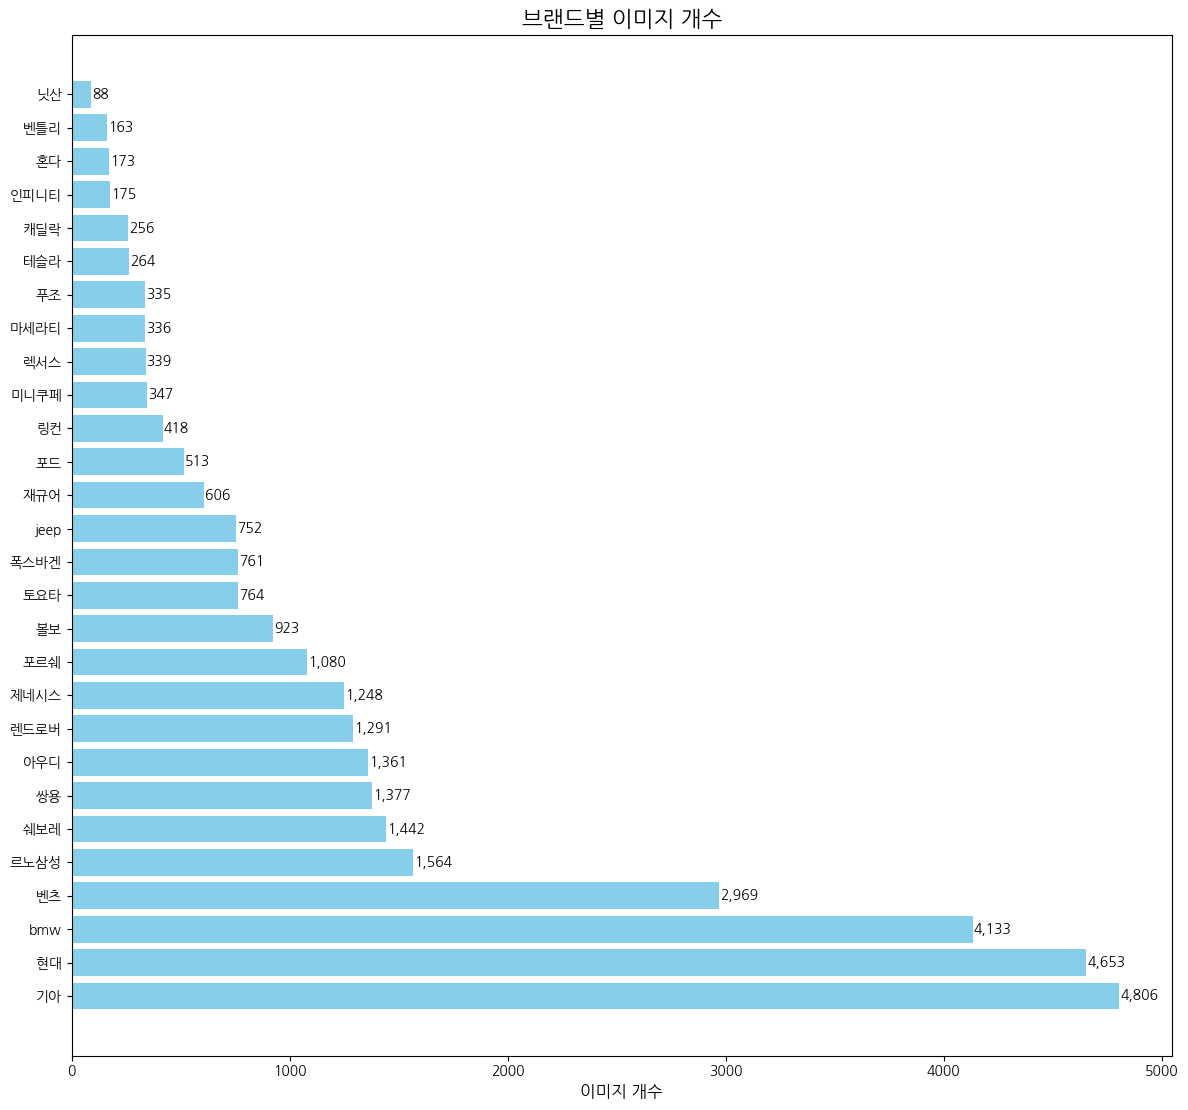

In [1]:
import os
import glob
import matplotlib.pyplot as plt
import koreanize_matplotlib
from collections import defaultdict

# 1. self_classification.txt 파일에서 브랜드와 클래스명 추출
def extract_brands_and_classes(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    brands_classes = {}
    current_brand = None
    
    # 브랜드 섹션으로 분리
    sections = content.split('==============================================================================')
    
    for section in sections:
        section = section.strip()
        if not section:
            continue
        
        lines = section.split('\n')
        
        # 첫 번째 줄이 브랜드명
        if len(lines) >= 1 and not (lines[0].startswith('"C:') or lines[0].startswith('"\\\\wsl')):
            current_brand = lines[0].strip()
            brands_classes[current_brand] = []
        
        # 클래스명 추출 (경로의 마지막 부분)
        for line in lines:
            if line.startswith('"'):
                path = line.strip('"')
                if '\\' in path:
                    last_part = path.split('\\')[-1]
                else:
                    last_part = path.split('/')[-1]
                
                if last_part and current_brand and last_part not in brands_classes[current_brand]:
                    brands_classes[current_brand].append(last_part)
    
    return brands_classes

# 2. 각 클래스 폴더에서 이미지 개수 세기
def count_images_in_classes(root_dir, brands_classes):
    class_image_counts = {}
    brand_image_counts = defaultdict(int)
    
    for brand, classes in brands_classes.items():
        for class_name in classes:
            class_path = os.path.join(root_dir, class_name)
            
            if not os.path.exists(class_path):
                print(f"경로 없음: {class_path}")
                class_image_counts[class_name] = 0
                continue
            
            # 이미지 파일 개수 세기
            image_count = 0
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tif', '*.tiff']:
                files = glob.glob(os.path.join(class_path, "**", ext), recursive=True)
                image_count += len(files)
            
            class_image_counts[class_name] = image_count
            brand_image_counts[brand] += image_count
    
    return class_image_counts, brand_image_counts

# 3. 브랜드별 이미지 개수 시각화
def plot_brand_statistics(brand_counts):
    # 이미지 수 기준 내림차순 정렬
    sorted_brands = sorted(brand_counts.items(), key=lambda x: x[1], reverse=True)
    brands = [b[0] for b in sorted_brands]
    counts = [b[1] for b in sorted_brands]
    
    plt.figure(figsize=(12, max(8, len(brands) * 0.4)))
    bars = plt.barh(brands, counts, color='skyblue')
    
    # 막대 위에 숫자 표시
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
                 f"{counts[i]:,}", va='center')
    
    plt.title('브랜드별 이미지 개수', fontsize=16)
    plt.xlabel('이미지 개수', fontsize=12)
    plt.tight_layout()
    plt.savefig('brand_statistics.png')
    plt.show()

# 실행 코드
file_path = "./self_classification.txt"
root_dir = "C:\\Users\\tjdwn\\OneDrive\\Desktop\\hectoData\\open\\rm_bg_train"

# 브랜드 및 클래스 정보 추출
brands_classes = extract_brands_and_classes(file_path)

# 이미지 개수 세기
class_image_counts, brand_image_counts = count_images_in_classes(root_dir, brands_classes)

# 결과 출력
print("## 브랜드 및 클래스별 통계\n")
for brand, classes in brands_classes.items():
    total_images = sum(class_image_counts.get(cls, 0) for cls in classes)
    print(f"### {brand} ({len(classes)}개 클래스, {total_images}개 이미지)")
    for class_name in classes:
        print(f"- {class_name}: {class_image_counts.get(class_name, 0)}개 이미지")
    print()

print("## 전체 통계")
print(f"총 브랜드 수: {len(brands_classes)}개")
print(f"총 클래스 수: {sum(len(classes) for classes in brands_classes.values())}개")
print(f"총 이미지 수: {sum(brand_image_counts.values())}개")

# 브랜드별 통계 시각화
plot_brand_statistics(brand_image_counts)

브랜드 그룹별 총 클래스396


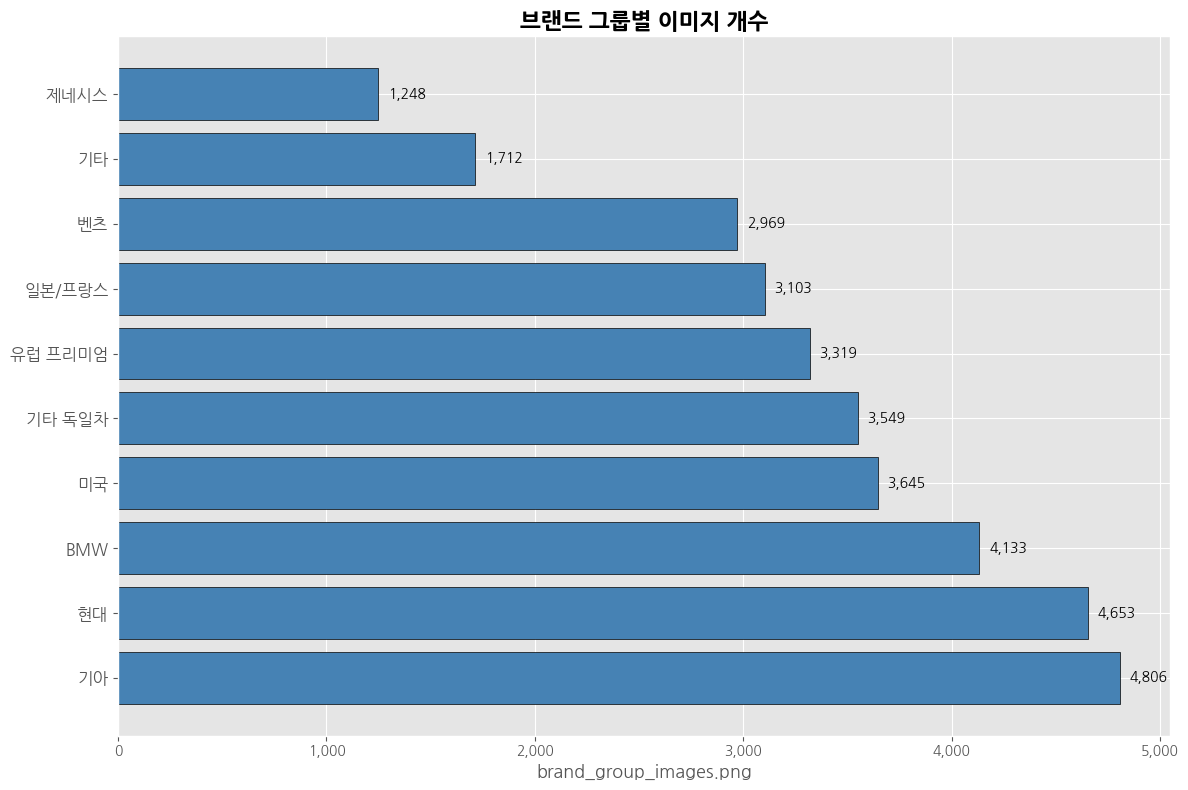

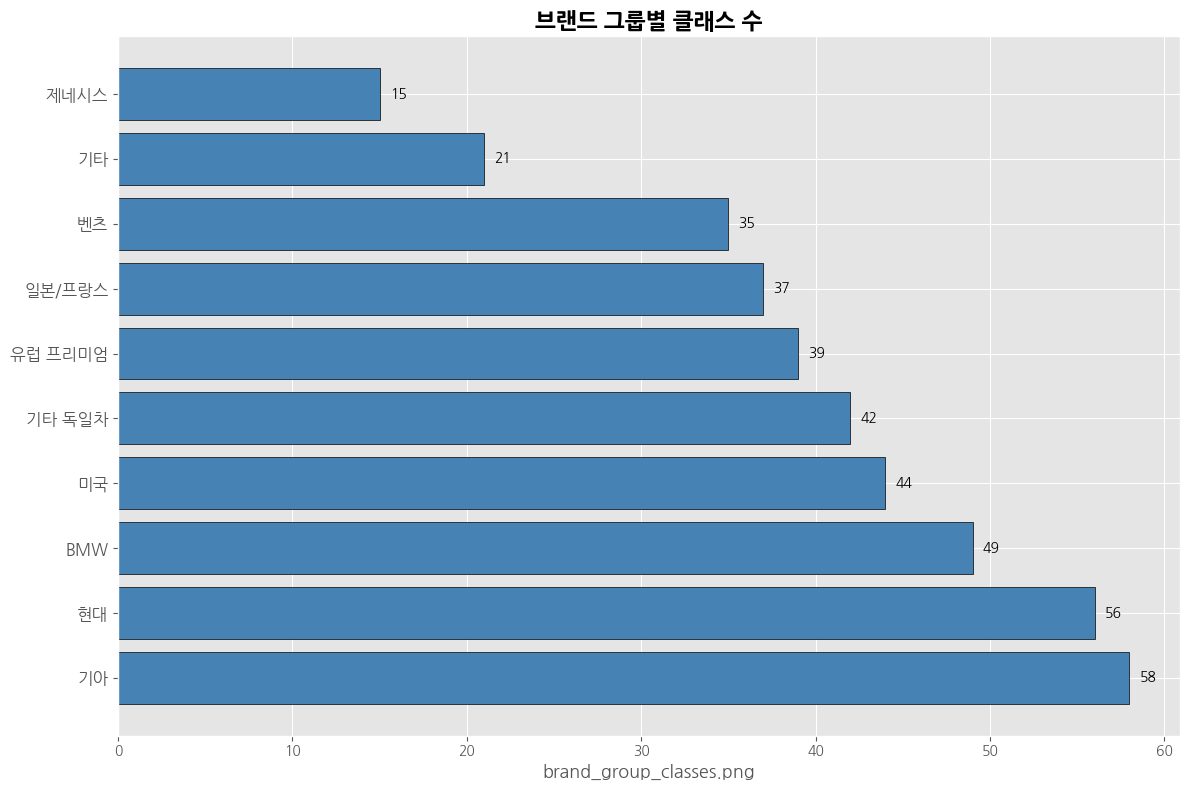


## 브랜드 그룹별 통계
- 기아: 4,806개 이미지, 58개 클래스
- 현대: 4,653개 이미지, 56개 클래스
- BMW: 4,133개 이미지, 49개 클래스
- 미국: 3,645개 이미지, 44개 클래스
- 기타 독일차: 3,549개 이미지, 42개 클래스
- 유럽 프리미엄: 3,319개 이미지, 39개 클래스
- 일본/프랑스: 3,103개 이미지, 37개 클래스
- 벤츠: 2,969개 이미지, 35개 클래스
- 기타: 1,712개 이미지, 21개 클래스
- 제네시스: 1,248개 이미지, 15개 클래스


In [13]:
import matplotlib.ticker as ticker
# 브랜드 그룹 매핑
brand_to_group = {
    "현대": "현대",
    "기아": "기아",
    "제네시스": "제네시스",
    "bmw": "BMW",
    "벤츠": "벤츠",
    "포르쉐": "기타 독일차",
    "폭스바겐": "기타 독일차",
    "미니쿠페": "기타 독일차",
    "아우디": "기타 독일차", # 아우디를 기타 독일차로 이동
    "푸조": "기타",
    "캐딜락": "미국",
    "재규어": "유럽 프리미엄",
    "렉서스": "일본/프랑스", # 일본 브랜드로 이동
    "포드": "미국",
    "링컨": "미국",
    "인피니티": "일본/프랑스", # 일본 브랜드로 이동
    "르노삼성": "일본/프랑스", # 프랑스계를 일본/프랑스로 통합
    "토요타": "일본/프랑스", # 일본 브랜드로 이동
    "볼보": "유럽 프리미엄",
    "jeep": "미국",
    "마세라티": "유럽 프리미엄",
    "쌍용": "기타",
    "쉐보레": "미국",
    "렌드로버": "유럽 프리미엄",
    "테슬라": "미국",
    "닛산": "일본/프랑스", # 일본 브랜드로 이동
    "혼다": "일본/프랑스", # 일본 브랜드로 이동
    "벤틀리": "유럽 프리미엄"
}


def get_brand_group_counts(brand_counts):
    # 그룹별 이미지 개수 계산
    group_counts = defaultdict(int)
    for brand, count in brand_counts.items():
        group = brand_to_group.get(brand.lower(), "기타")
        group_counts[group] += count
    
    return dict(group_counts)

# 브랜드 그룹별 클래스 수 계산
def get_brand_group_class_counts(brands_classes, brand_to_group):
    group_class_counts = defaultdict(int)
    class_counts = 0
    for brand, classes in brands_classes.items():
        group = brand_to_group.get(brand.lower(), "기타")
        group_class_counts[group] += len(classes)
        class_counts += len(classes)
    print(f"브랜드 그룹별 총 클래스{class_counts}")
    return dict(group_class_counts)

def plot_grouped_statistics(data_dict, title, xlabel='개수', filename=None):
    # 정렬
    sorted_items = sorted(data_dict.items(), key=lambda x: x[1], reverse=True)
    labels = [item[0] for item in sorted_items]
    values = [item[1] for item in sorted_items]

    # 스타일 설정
    plt.style.use('ggplot')
    fig, ax = plt.subplots(figsize=(12, 8))

    # 막대 그래프
    bars = ax.barh(labels, values, color='steelblue', edgecolor='black')

    # 수치 표시
    for bar in bars:
        width = bar.get_width()
        ax.text(width + max(values) * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{int(width):,}', va='center', fontsize=10)

    # 축 설정
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_title(title, fontsize=16, weight='bold')
    ax.tick_params(axis='y', labelsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# 브랜드 그룹별 통계 계산
brand_group_counts = get_brand_group_counts(brand_image_counts)
brand_group_class_counts = get_brand_group_class_counts(brands_classes, brand_to_group)

# 브랜드 그룹별 이미지 개수 시각화
plot_grouped_statistics(brand_group_counts, '브랜드 그룹별 이미지 개수', 'brand_group_images.png')

# 브랜드 그룹별 클래스 개수 시각화
plot_grouped_statistics(brand_group_class_counts, '브랜드 그룹별 클래스 수', 'brand_group_classes.png')

# 결과 출력
print("\n## 브랜드 그룹별 통계")
for group, count in sorted(brand_group_counts.items(), key=lambda x: x[1], reverse=True):
    class_count = brand_group_class_counts[group]
    print(f"- {group}: {count:,}개 이미지, {class_count}개 클래스")


In [14]:
import csv
import os
from collections import defaultdict

def create_relabeling_csv(brands_classes, brand_to_group, output_path="car_class_mapping.csv"):
    """
    클래스 재레이블링을 위한 CSV 파일 생성
    
    Args:
        brands_classes: 브랜드별 클래스 목록 딕셔너리
        brand_to_group: 브랜드에서 그룹으로의 매핑 딕셔너리
        output_path: 출력 CSV 파일 경로
    """
    # CSV 헤더
    headers = ["original_class", "brand", "new_group"]
    rows = []
    
    # 모든 클래스에 대해 재레이블링 정보 생성
    for brand, classes in brands_classes.items():
        brand_lower = brand.lower()
        group = brand_to_group.get(brand_lower, "기타")
        
        for class_name in classes:
            rows.append({
                "original_class": class_name,
                "brand": brand,
                "new_group": group
            })
    
    # CSV 파일로 저장
    with open(output_path, 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=headers)
        writer.writeheader()
        writer.writerows(rows)
    
    print(f"재레이블링 매핑이 {output_path}에 저장되었습니다.")
    return output_path

# 브랜드 및 클래스 정보 추출 후 CSV 생성
brands_classes = extract_brands_and_classes(file_path)
csv_path = create_relabeling_csv(brands_classes, brand_to_group)

재레이블링 매핑이 car_class_mapping.csv에 저장되었습니다.


# 재 레이블링 테스트 학습

# 컬러분석

🚗 클래스별 차량 색상 분석 시작
원본 이미지: C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\train
마스크: C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\extracted_mask
출력 디렉토리: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis
모든 클래스의 모든 차량 색상 분석 시작...
총 396개 클래스 발견


전체 클래스 분석: 100%|██████████| 396/396 [27:30<00:00,  4.17s/it]



📊 전체 분석 통계
총 클래스: 396개
분석된 클래스: 396개 (100.0%)
총 이미지 파일: 33,137개
마스크 없음: 0개 (0.0%)
차량픽셀 부족: 7개 (0.0%)
색상추출 실패: 34개 (0.1%)
성공 처리: 33,096개 (99.9%)

=== 전체 클래스별 색상 분포 비교 (396개 클래스) ===

전체 클래스별 주요 색상 (이미지 수 5개 이상인 클래스만):

프리우스_4세대_2019_2022 (총 90대):
  Black: 71대 (78.9%)
  Gray: 9대 (10.0%)
  Silver: 6대 (6.7%)
  Red: 2대 (2.2%)
  Blue: 1대 (1.1%)
  Purple: 1대 (1.1%)

3시리즈_E90_2005_2012 (총 88대):
  Black: 56대 (63.6%)
  Silver: 16대 (18.2%)
  Gray: 13대 (14.8%)
  Blue: 3대 (3.4%)

3시리즈_F30_2013_2018 (총 88대):
  Black: 55대 (62.5%)
  Silver: 23대 (26.1%)
  Gray: 7대 (8.0%)
  White: 2대 (2.3%)
  Orange: 1대 (1.1%)

3시리즈_GT_F34_2014_2021 (총 88대):
  Black: 62대 (70.5%)
  Silver: 14대 (15.9%)
  Gray: 8대 (9.1%)
  White: 3대 (3.4%)
  Purple: 1대 (1.1%)

4시리즈_F32_2014_2020 (총 88대):
  Black: 62대 (70.5%)
  Silver: 10대 (11.4%)
  White: 9대 (10.2%)
  Purple: 3대 (3.4%)
  Red: 3대 (3.4%)
  Gray: 1대 (1.1%)

7시리즈_G11_2019_2022 (총 88대):
  Black: 72대 (81.8%)
  Gray: 9대 (10.2%)
  Silver: 6대 (6.8%)
  White: 1대 (1.1%)

A5_F5_2019_

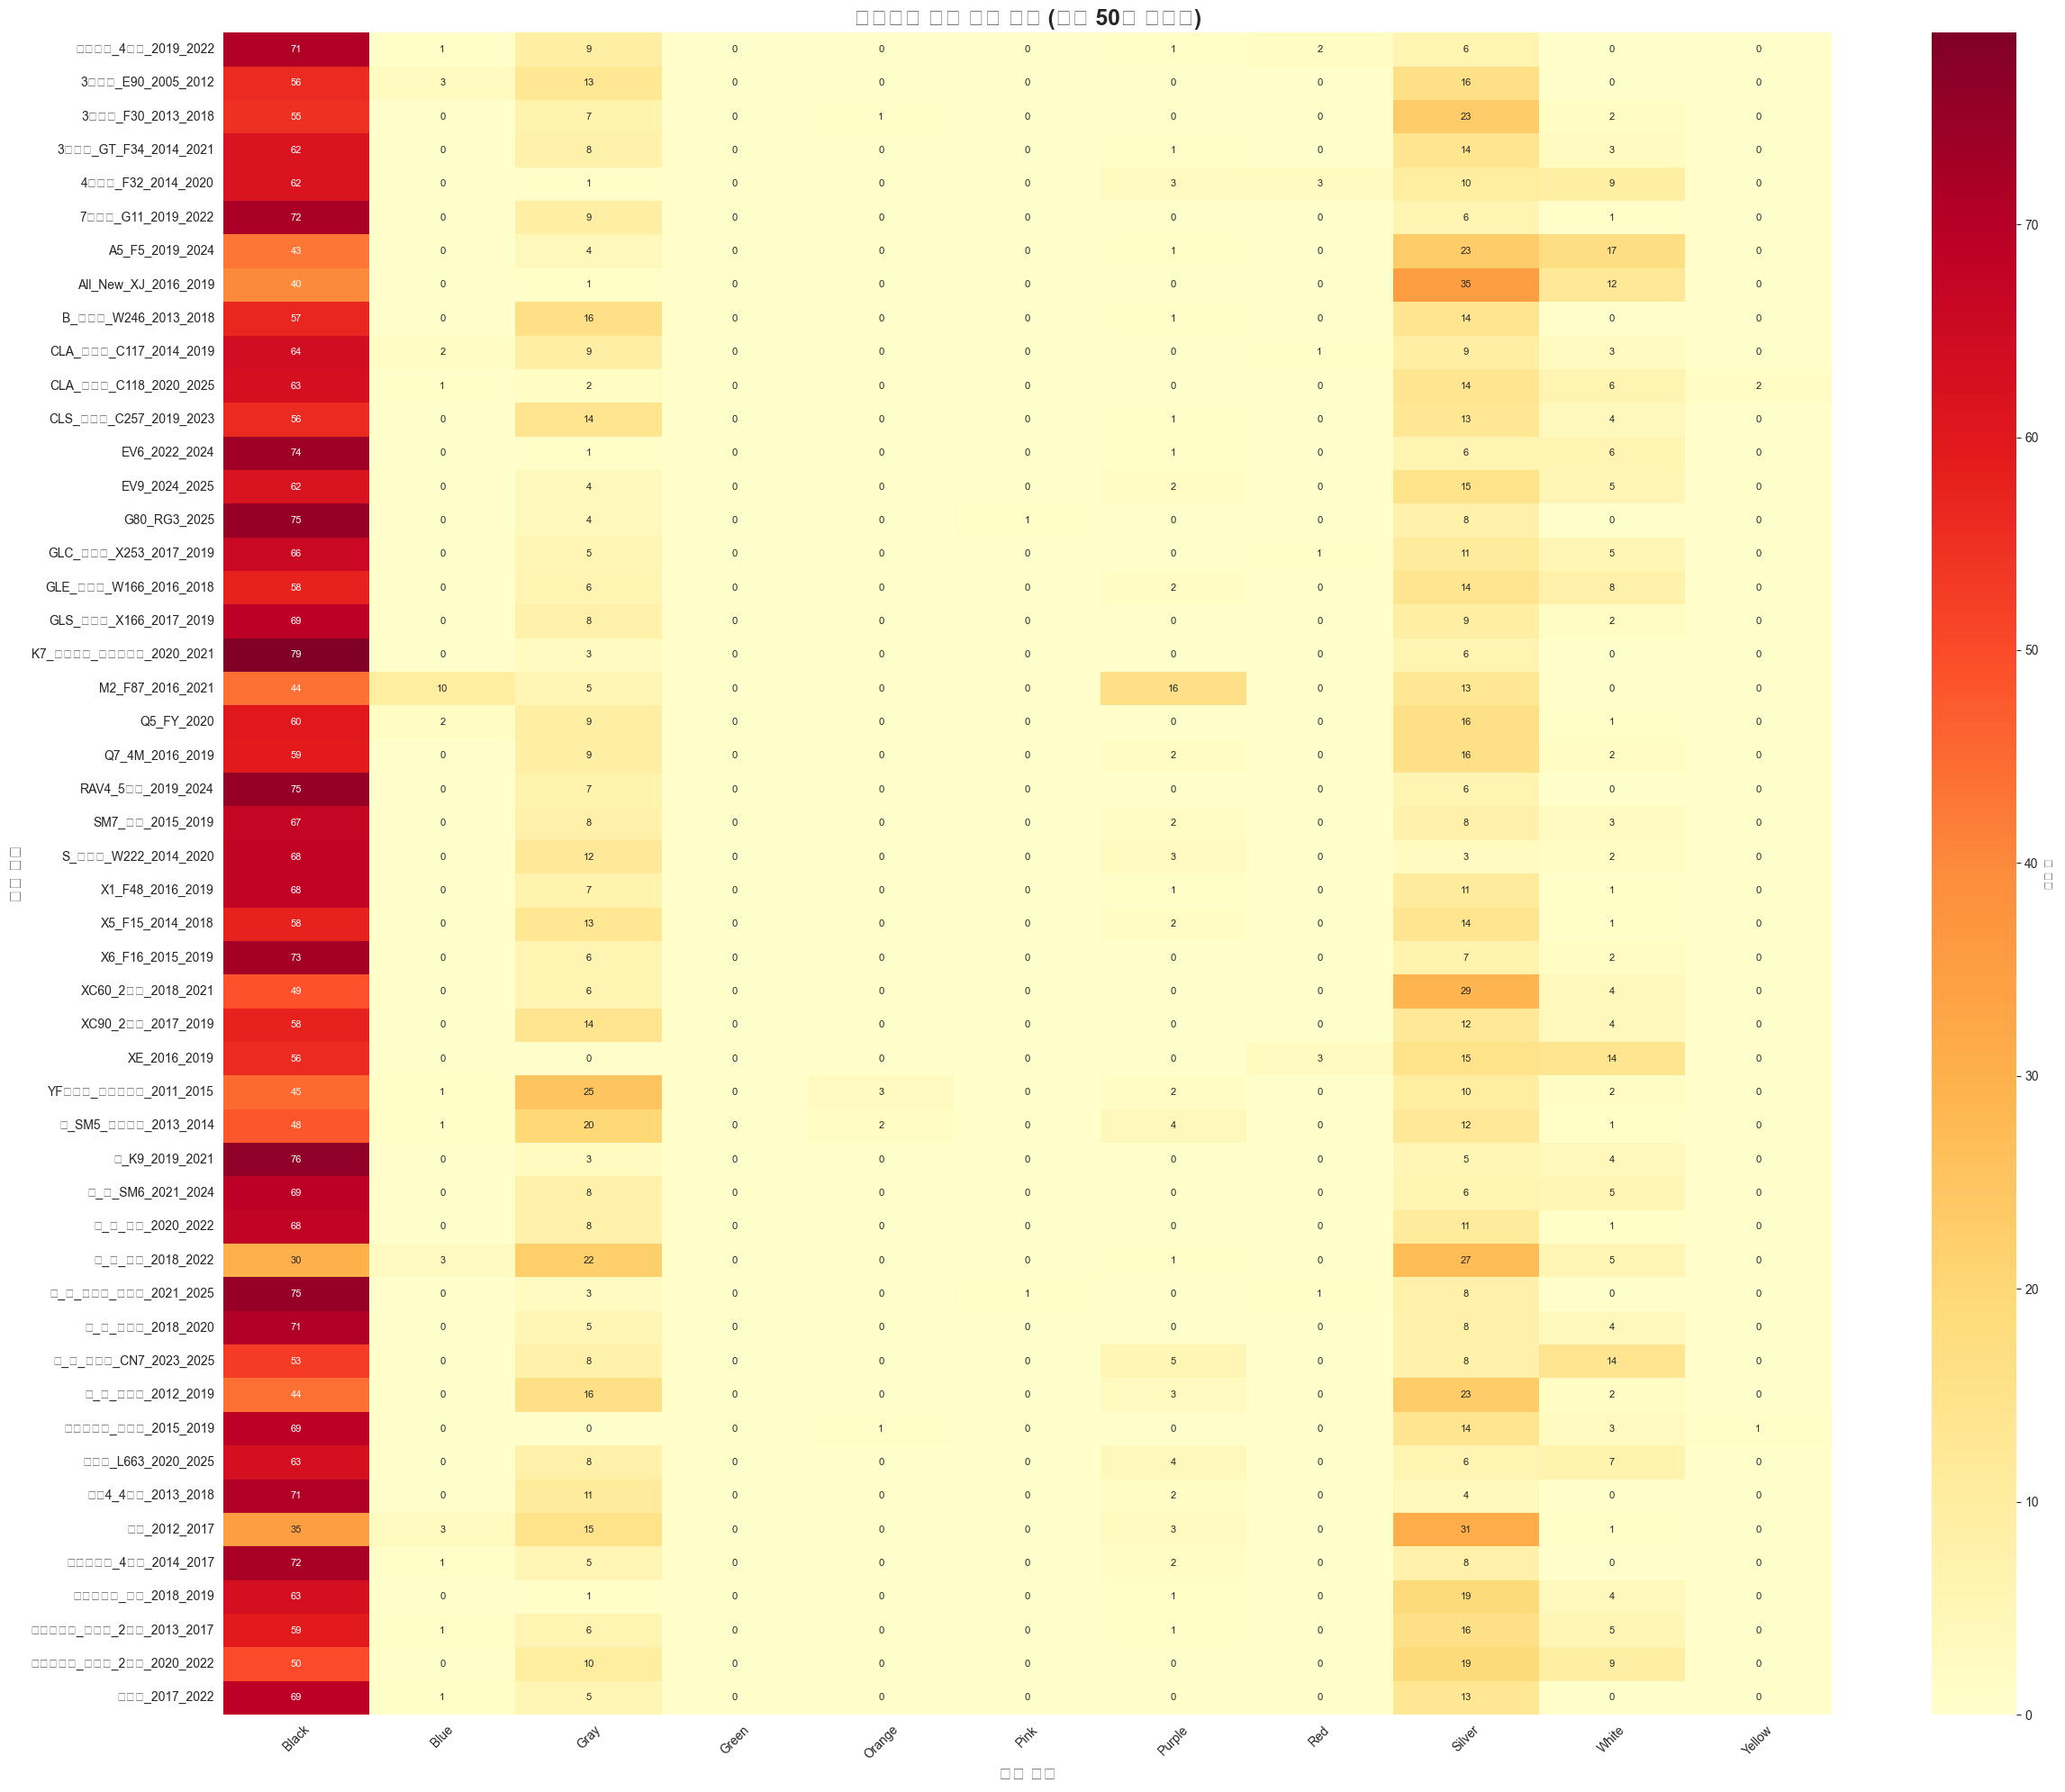

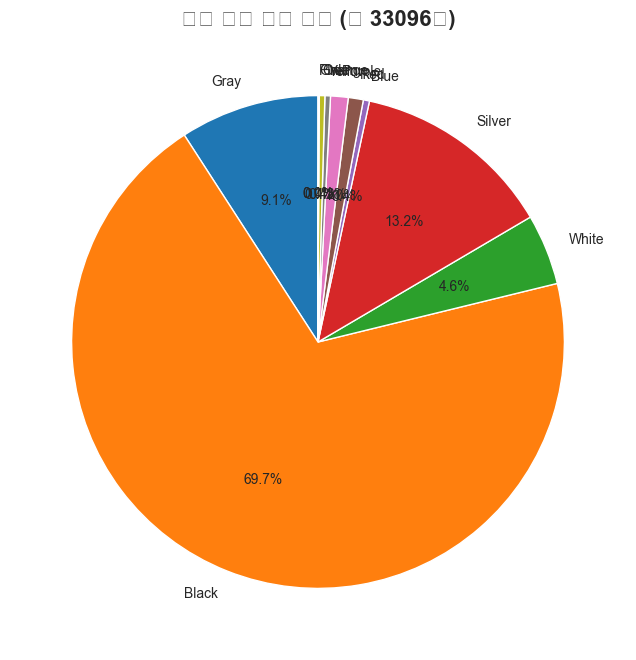

클래스 비교 히트맵 저장: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\all_class_color_comparison_heatmap.png
전체 색상 분포 저장: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\total_color_distribution.png
클래스별 결과 저장 완료:
  - 요약 통계: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\class_wise_color_summary.csv
  - 색상 매트릭스: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\class_color_matrix.csv
  - 상세 결과: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\class_wise_color_details.csv

🎉 클래스별 분석 완료!
총 396개 클래스 분석됨


In [3]:
# 이규상 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import cv2
from sklearn.cluster import KMeans
from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')


class ClassWiseColorAnalyzer:
    """클래스별 차량 색상 분석기"""
    
    def __init__(self, train_dir, mask_dir):
        self.train_dir = train_dir
        self.mask_dir = mask_dir
        self.class_results = defaultdict(list)
        self.class_stats = {}
        
    def find_matching_mask(self, image_path, class_name):
        """이미지에 대응하는 마스크 파일 찾기"""
        img_filename = os.path.basename(image_path)
        base_name = os.path.splitext(img_filename)[0]
        class_mask_dir = os.path.join(self.mask_dir, class_name)
        
        if not os.path.exists(class_mask_dir):
            return None
        
        possible_patterns = [
            f"{base_name}_mask.png",
            f"{base_name}.png",
            f"{base_name}_mask.jpg",
            f"{base_name}.jpg",
        ]
        
        for pattern in possible_patterns:
            mask_path = os.path.join(class_mask_dir, pattern)
            if os.path.exists(mask_path):
                return mask_path
        
        return None
    
    def extract_car_pixels(self, image_path, mask_path):
        """마스크를 사용해 차량 픽셀만 추출 (한글 경로 지원)"""
        try:
            # PIL로 이미지 로드 (한글 경로 지원)
            image_pil = Image.open(image_path).convert('RGB')
            image_rgb = np.array(image_pil)
            
            # PIL로 마스크 로드
            mask_pil = Image.open(mask_path).convert('L')
            mask = np.array(mask_pil)
            
            # 마스크 크기 조정
            if mask.shape != image_rgb.shape[:2]:
                mask_pil_resized = mask_pil.resize((image_rgb.shape[1], image_rgb.shape[0]), Image.LANCZOS)
                mask = np.array(mask_pil_resized)
            
            # 마스크가 적용된 픽셀만 추출
            car_pixels = image_rgb[mask > 128]
            
            return car_pixels if len(car_pixels) > 100 else None
            
        except Exception as e:
            print(f"❌ 이미지 로드 실패: {image_path} - {e}")
            return None
    
    def extract_dominant_color(self, car_pixels, threshold_ratio=0.25):
        """차량 픽셀에서 주요 색상 추출 (PIL 기반)"""
        if len(car_pixels) < 100:
            return None
        
        # 샘플링
        max_pixels = 20000
        if len(car_pixels) > max_pixels:
            indices = np.random.choice(len(car_pixels), max_pixels, replace=False)
            car_pixels = car_pixels[indices]
        
        # PIL + numpy로 HSV 변환 (OpenCV 대신)
        try:
            # RGB to HSV 변환 (PIL 방식)
            pixels_pil = Image.fromarray(car_pixels.reshape(-1, 1, 3).astype(np.uint8))
            pixels_hsv_pil = pixels_pil.convert('HSV')
            pixels_hsv = np.array(pixels_hsv_pil).reshape(-1, 3)
            
            # 유효한 픽셀 필터링
            valid_mask = (pixels_hsv[:, 1] > 15) & (pixels_hsv[:, 2] > 25) & (pixels_hsv[:, 2] < 245)
            filtered_pixels = car_pixels[valid_mask]
            
        except:
            # HSV 변환 실패 시 원본 픽셀 사용
            filtered_pixels = car_pixels
        
        if len(filtered_pixels) < 50:
            return None
        
        # K-means 클러스터링
        n_clusters = min(4, len(filtered_pixels) // 200)
        if n_clusters < 2:
            n_clusters = 2
        
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans.fit(filtered_pixels)
        
        # 클러스터 비율 계산
        labels = kmeans.labels_
        counts = np.bincount(labels)
        percentages = counts / len(labels)
        
        # 가장 큰 클러스터 선택
        dominant_cluster_idx = np.argmax(percentages)
        dominant_color = kmeans.cluster_centers_[dominant_cluster_idx].astype(int)
        max_percentage = percentages[dominant_cluster_idx]
        
        return {
            'dominant_color': tuple(dominant_color),
            'percentage': max_percentage,
            'total_pixels': len(filtered_pixels),
            'cluster_centers': kmeans.cluster_centers_.astype(int),
            'cluster_percentages': percentages
        }

    
    def analyze_class(self, class_name):
        """특정 클래스의 색상 분석 (상세 통계 포함)"""
        class_dir = os.path.join(self.train_dir, class_name)
        if not os.path.exists(class_dir):
            return None
        
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        class_colors = []
        
        # 통계 변수들
        total_files = len(image_files)
        no_mask_count = 0
        no_car_pixels_count = 0
        no_color_info_count = 0
        success_count = 0
        
        for img_file in image_files:
            img_path = os.path.join(class_dir, img_file)
            mask_path = self.find_matching_mask(img_path, class_name)
            
            if mask_path is None:
                no_mask_count += 1
                continue
            
            # 차량 픽셀 추출
            car_pixels = self.extract_car_pixels(img_path, mask_path)
            if car_pixels is None:
                no_car_pixels_count += 1
                continue
            
            # 주요 색상 추출
            color_info = self.extract_dominant_color(car_pixels)
            if color_info is None:
                no_color_info_count += 1
                continue
            
            # 색상 분류
            dominant_color = color_info['dominant_color']
            color_category = self.classify_color(dominant_color)
            
            result = {
                'image_path': img_path,
                'dominant_color_rgb': dominant_color,
                'color_category': color_category,
                'percentage': color_info['percentage'],
                'total_pixels': color_info['total_pixels']
            }
            
            class_colors.append(result)
            success_count += 1
        
        # 클래스별 상세 통계 출력 (문제가 있는 클래스만)
        if total_files > 0:
            success_rate = success_count / total_files * 100
            if success_rate < 50:  # 성공률이 50% 미만인 클래스만 출력
                print(f"\n⚠️  {class_name} 분석 결과:")
                print(f"  총 파일: {total_files}개")
                print(f"  마스크 없음: {no_mask_count}개 ({no_mask_count/total_files*100:.1f}%)")
                print(f"  차량픽셀 없음: {no_car_pixels_count}개 ({no_car_pixels_count/total_files*100:.1f}%)")
                print(f"  색상추출 실패: {no_color_info_count}개 ({no_color_info_count/total_files*100:.1f}%)")
                print(f"  성공: {success_count}개 ({success_rate:.1f}%)")
        
        self.class_results[class_name] = class_colors
        
        # 클래스별 통계 계산
        if class_colors:
            color_counts = Counter([result['color_category'] for result in class_colors])
            total_images = len(class_colors)
            
            self.class_stats[class_name] = {
                'total_images': total_images,
                'total_files': total_files,
                'processed_ratio': success_count / total_files,
                'no_mask_count': no_mask_count,
                'no_car_pixels_count': no_car_pixels_count,
                'no_color_info_count': no_color_info_count,
                'success_count': success_count,
                'color_distribution': dict(color_counts),
                'color_percentages': {color: (count / total_images * 100) 
                                    for color, count in color_counts.items()},
                'dominant_color': color_counts.most_common(1)[0][0] if color_counts else None
            }
        
        return success_count

    def analyze_all_classes(self, min_images=1):
        """모든 클래스 분석 (상세 통계 포함)"""
        print("모든 클래스의 모든 차량 색상 분석 시작...")
        
        class_names = [d for d in os.listdir(self.train_dir) 
                      if os.path.isdir(os.path.join(self.train_dir, d))]
        
        print(f"총 {len(class_names)}개 클래스 발견")
        
        # 전체 통계 변수들
        total_classes = len(class_names)
        processed_classes = 0
        total_files = 0
        total_no_mask = 0
        total_no_car_pixels = 0
        total_no_color_info = 0
        total_success = 0
        
        for class_name in tqdm(class_names, desc="전체 클래스 분석"):
            success_count = self.analyze_class(class_name)
            
            if success_count and success_count >= min_images:
                processed_classes += 1
            
            # 전체 통계 누적
            if class_name in self.class_stats:
                stats = self.class_stats[class_name]
                total_files += stats.get('total_files', 0)
                total_no_mask += stats.get('no_mask_count', 0)
                total_no_car_pixels += stats.get('no_car_pixels_count', 0)
                total_no_color_info += stats.get('no_color_info_count', 0)
                total_success += stats.get('success_count', 0)
        
        # 전체 통계 출력
        print(f"\n" + "="*60)
        print(f"📊 전체 분석 통계")
        print(f"="*60)
        print(f"총 클래스: {total_classes}개")
        print(f"분석된 클래스: {processed_classes}개 ({processed_classes/total_classes*100:.1f}%)")
        print(f"총 이미지 파일: {total_files:,}개")
        print(f"마스크 없음: {total_no_mask:,}개 ({total_no_mask/total_files*100:.1f}%)")
        print(f"차량픽셀 부족: {total_no_car_pixels:,}개 ({total_no_car_pixels/total_files*100:.1f}%)")
        print(f"색상추출 실패: {total_no_color_info:,}개 ({total_no_color_info/total_files*100:.1f}%)")
        print(f"성공 처리: {total_success:,}개 ({total_success/total_files*100:.1f}%)")
        print(f"="*60)
        
        # 최소 이미지 수 기준으로 필터링
        filtered_stats = {class_name: stats for class_name, stats in self.class_stats.items() 
                         if stats['total_images'] >= min_images}
        
        self.class_stats = filtered_stats
        
        return self.class_stats
    
    def create_comparison_analysis(self):
        """모든 클래스 간 색상 비교 분석"""
        if not self.class_stats:
            print("분석된 클래스가 없습니다.")
            return None
        
        print(f"\n=== 전체 클래스별 색상 분포 비교 ({len(self.class_stats)}개 클래스) ===")
        
        # 전체 색상 카테고리 수집
        all_colors = set()
        for stats in self.class_stats.values():
            all_colors.update(stats['color_distribution'].keys())
        all_colors = sorted(list(all_colors))
        
        # 클래스별 색상 매트릭스 생성 (모든 클래스)
        class_color_matrix = []
        class_names = []
        
        for class_name, stats in sorted(self.class_stats.items(), 
                                       key=lambda x: x[1]['total_images'], 
                                       reverse=True):
            class_names.append(class_name)
            color_row = [stats['color_distribution'].get(color, 0) for color in all_colors]
            class_color_matrix.append(color_row)
        
        # 전체 클래스별 주요 색상 출력 (제한 없음)
        print("\n전체 클래스별 주요 색상 (이미지 수 5개 이상인 클래스만):")
        
        for class_name in class_names:
            stats = self.class_stats[class_name]
            if stats['total_images'] >= 5:  # 최소 5개 이상만 출력
                color_dist = stats['color_distribution']
                sorted_colors = sorted(color_dist.items(), key=lambda x: x[1], reverse=True)
                
                print(f"\n{class_name} (총 {stats['total_images']}대):")
                for color, count in sorted_colors:  # 모든 색상 출력
                    percentage = stats['color_percentages'][color]
                    print(f"  {color}: {count}대 ({percentage:.1f}%)")
        
        # 전체 통계 계산
        total_color_distribution = defaultdict(int)
        total_images = 0
        
        for stats in self.class_stats.values():
            total_images += stats['total_images']
            for color, count in stats['color_distribution'].items():
                total_color_distribution[color] += count
        
        print(f"\n=== 전체 차량 색상 분포 요약 ===")
        print(f"총 분석된 차량: {total_images}대")
        
        sorted_total_colors = sorted(total_color_distribution.items(), 
                                    key=lambda x: x[1], reverse=True)
        
        for color, count in sorted_total_colors:
            percentage = count / total_images * 100
            print(f"{color}: {count}대 ({percentage:.1f}%)")
        
        return {
            'color_matrix': class_color_matrix,
            'class_names': class_names,
            'color_categories': all_colors,
            'total_color_distribution': dict(total_color_distribution),
            'total_images': total_images
        }

    
    def find_color_patterns(self):
        """특정 색상 패턴 찾기"""
        print(f"\n=== 색상 패턴 분석 ===")
        
        # 브랜드별 색상 패턴
        brand_colors = defaultdict(lambda: defaultdict(int))
        
        for class_name, stats in self.class_stats.items():
            # 브랜드 추출 (첫 번째 단어 또는 언더스코어 전)
            if '_' in class_name:
                brand = class_name.split('_')[0]
            else:
                # 한글 브랜드명 처리
                korean_brands = ['현대', '기아', '제네시스', '쌍용', '쉐보레']
                brand = None
                for kb in korean_brands:
                    if kb in class_name:
                        brand = kb
                        break
                if brand is None:
                    brand = class_name[:10]  # 첫 10글자
            
            for color, count in stats['color_distribution'].items():
                brand_colors[brand][color] += count
        
        # 브랜드별 주요 색상 출력
        print("브랜드별 주요 색상 선호도 (상위 10개 브랜드):")
        sorted_brands = sorted(brand_colors.items(), 
                              key=lambda x: sum(x[1].values()), 
                              reverse=True)
        
        for brand, colors in sorted_brands[:10]:
            total_cars = sum(colors.values())
            sorted_colors = sorted(colors.items(), key=lambda x: x[1], reverse=True)
            
            print(f"\n{brand} (총 {total_cars}대):")
            for color, count in sorted_colors[:3]:
                percentage = count / total_cars * 100
                print(f"  {color}: {count}대 ({percentage:.1f}%)")
        
        # 특정 색상이 많은 클래스 찾기
        print(f"\n특정 색상 클래스 분석:")
        color_dominant_classes = defaultdict(list)
        
        for class_name, stats in self.class_stats.items():
            for color, percentage in stats['color_percentages'].items():
                if percentage > 50:  # 50% 이상인 경우
                    color_dominant_classes[color].append((class_name, percentage))
        
        for color, classes in color_dominant_classes.items():
            if len(classes) > 0:
                classes.sort(key=lambda x: x[1], reverse=True)
                print(f"\n{color} 위주 클래스 (50% 이상):")
                for class_name, percentage in classes[:5]:
                    print(f"  {class_name}: {percentage:.1f}%")
        
        return brand_colors, color_dominant_classes
    
    def save_class_results(self, comparison_data, output_dir):
        """클래스별 결과 저장"""
        os.makedirs(output_dir, exist_ok=True)
        
        # 1. 클래스별 상세 통계
        class_summary = []
        for class_name, stats in self.class_stats.items():
            row = {
                '클래스명': class_name,
                '총_이미지수': stats['total_images'],
                '처리율(%)': round(stats['processed_ratio'] * 100, 1),
                '주요_색상': stats['dominant_color']
            }
            
            # 각 색상별 비율 추가
            for color, percentage in stats['color_percentages'].items():
                row[f'{color}_비율(%)'] = round(percentage, 1)
            
            class_summary.append(row)
        
        summary_df = pd.DataFrame(class_summary)
        summary_path = os.path.join(output_dir, 'class_wise_color_summary.csv')
        summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
        
        # 2. 색상 매트릭스
        matrix_df = pd.DataFrame(
            comparison_data['color_matrix'],
            index=comparison_data['class_names'],
            columns=comparison_data['color_categories']
        )
        matrix_path = os.path.join(output_dir, 'class_color_matrix.csv')
        matrix_df.to_csv(matrix_path, encoding='utf-8-sig')
        
        # 3. 상세 결과 (각 이미지별)
        all_details = []
        for class_name, results in self.class_results.items():
            for result in results:
                detail_row = {
                    '클래스명': class_name,
                    '이미지경로': result['image_path'],
                    'RGB': str(result['dominant_color_rgb']),
                    '색상범주': result['color_category'],
                    '비율(%)': round(result['percentage'] * 100, 1),
                    '총픽셀수': result['total_pixels']
                }
                all_details.append(detail_row)
        
        details_df = pd.DataFrame(all_details)
        details_path = os.path.join(output_dir, 'class_wise_color_details.csv')
        details_df.to_csv(details_path, index=False, encoding='utf-8-sig')
        
        print(f"클래스별 결과 저장 완료:")
        print(f"  - 요약 통계: {summary_path}")
        print(f"  - 색상 매트릭스: {matrix_path}")
        print(f"  - 상세 결과: {details_path}")

    def classify_color(self, rgb_color):
        """RGB 색상을 범주로 분류 (PIL 기반 HSV 변환)"""
        r, g, b = rgb_color
        
        try:
            # PIL로 HSV 변환
            rgb_img = Image.new('RGB', (1, 1), (int(r), int(g), int(b)))
            hsv_img = rgb_img.convert('HSV')
            h, s, v = hsv_img.getpixel((0, 0))
            
            # HSV 값 정규화 (PIL은 0-255 범위)
            h = h * 360 / 255  # 0-360도
            s = s * 100 / 255  # 0-100%
            v = v * 100 / 255  # 0-100%
            
        except:
            # HSV 변환 실패 시 RGB 값으로 대략적 판단
            brightness = (r + g + b) / 3
            
            if brightness < 60:
                return 'Black'
            elif brightness > 200:
                return 'White'
            else:
                return 'Gray'
        
        # 무채색 판단
        if s < 20:  # 채도가 낮음
            if v < 25:
                return 'Black'
            elif v > 85:
                return 'White'
            elif v > 60:
                return 'Silver'
            else:
                return 'Gray'
        
        # 어두운 색상
        if v < 30:
            return 'Black'
        
        # 밝은 무채색
        if v > 80 and s < 30:
            return 'White'
        
        # 유채색 분류
        if h < 15 or h >= 345:  # 빨간색
            if s > 40:
                return 'Red'
            else:
                return 'Black'
        elif h < 45:
            return 'Orange'
        elif h < 75:
            return 'Yellow'
        elif h < 150:
            return 'Green'
        elif h < 210:
            return 'Blue'
        elif h < 270:
            return 'Purple'
        else:
            return 'Pink'
    def visualize_class_comparison(self, comparison_data, output_dir):
        """전체 클래스 비교 시각화 (더 큰 히트맵)"""
        os.makedirs(output_dir, exist_ok=True)
        
        # 이미지 수가 많은 상위 50개 클래스만 히트맵으로 (가독성 위해)
        matrix = comparison_data['color_matrix'][:50]
        class_names = comparison_data['class_names'][:50]
        color_categories = comparison_data['color_categories']
        
        # 클래스명 줄이기
        short_names = [name[:30] + '...' if len(name) > 30 else name 
                      for name in class_names]
        
        plt.figure(figsize=(25, 20))  # 더 큰 사이즈
        
        # 히트맵
        df_heatmap = pd.DataFrame(matrix, index=short_names, columns=color_categories)
        sns.heatmap(df_heatmap, annot=True, fmt='d', cmap='YlOrRd', 
                   cbar_kws={'label': '차량 수'}, 
                   annot_kws={'size': 8})  # 글자 크기 조정
        
        plt.title('클래스별 색상 분포 비교 (상위 50개 클래스)', fontsize=18, fontweight='bold')
        plt.xlabel('색상 범주', fontsize=14)
        plt.ylabel('차량 모델', fontsize=14)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        # 저장
        heatmap_path = os.path.join(output_dir, 'all_class_color_comparison_heatmap.png')
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        # 전체 색상 분포 파이차트 추가
        plt.figure(figsize=(12, 8))
        total_colors = comparison_data['total_color_distribution']
        colors = list(total_colors.keys())
        counts = list(total_colors.values())
        
        plt.pie(counts, labels=colors, autopct='%1.1f%%', startangle=90)
        plt.title(f'전체 차량 색상 분포 (총 {comparison_data["total_images"]}대)', 
                  fontsize=16, fontweight='bold')
        
        pie_path = os.path.join(output_dir, 'total_color_distribution.png')
        plt.savefig(pie_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"클래스 비교 히트맵 저장: {heatmap_path}")
        print(f"전체 색상 분포 저장: {pie_path}")
def main():
    """메인 실행 함수"""
    
    # 경로 설정
    TRAIN_DIR = r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\train"
    MASK_DIR = r"C:\Users\tjdwn\OneDrive\Desktop\hectoData\open\extracted_mask"
    OUTPUT_DIR = r"C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis"
    
    print("🚗 클래스별 차량 색상 분석 시작")
    print(f"원본 이미지: {TRAIN_DIR}")
    print(f"마스크: {MASK_DIR}")
    print(f"출력 디렉토리: {OUTPUT_DIR}")
    print("=" * 60)
    
    # 분석기 초기화
    analyzer = ClassWiseColorAnalyzer(TRAIN_DIR, MASK_DIR)
    
    # 1. 모든 클래스 분석
    class_stats = analyzer.analyze_all_classes(min_images=5)
    
    if not class_stats:
        print("분석할 수 있는 클래스가 없습니다.")
        return
    
    # 2. 클래스 간 비교 분석
    comparison_data = analyzer.create_comparison_analysis()
    
    # 3. 색상 패턴 찾기
    brand_colors, color_dominant_classes = analyzer.find_color_patterns()
    
    # 4. 시각화
    analyzer.visualize_class_comparison(comparison_data, OUTPUT_DIR)
    
    # 5. 결과 저장
    analyzer.save_class_results(comparison_data, OUTPUT_DIR)
    
    print(f"\n🎉 클래스별 분석 완료!")
    print(f"총 {len(class_stats)}개 클래스 분석됨")


if __name__ == "__main__":
    main()

🎨 차량 색상 대표값 분석 시작
입력 파일: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\class_wise_color_details.csv
출력 디렉토리: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\representative_colors
색상 분석 CSV 로드 중...
로드된 데이터: 33096행
컬럼명: ['클래스명', '이미지경로', 'RGB', '색상범주', '비율(%)', '총픽셀수']
RGB 값 파싱 중...
총 33096개 중 33096개 유효한 데이터

색상 카테고리별 대표 색상 추출:

Gray (3022개)
  원본 RGB 범위: R(64-64) G(52-153) B(64-64)
  이상치 제거 (IQR): 3022 → 3022개
  평균 RGB: (np.int64(64), np.int64(97), np.int64(64)) → #406140
  중앙값 RGB: (np.int64(64), np.int64(91), np.int64(64)) → #405b40
  표준편차: R(0.0) G(27.6) B(0.0)

Black (23065개)
  원본 RGB 범위: R(64-64) G(9-210) B(64-64)
  이상치 제거 (IQR): 23065 → 21905개
  평균 RGB: (np.int64(64), np.int64(34), np.int64(64)) → #402240
  중앙값 RGB: (np.int64(64), np.int64(34), np.int64(64)) → #402240
  표준편차: R(0.0) G(5.2) B(0.0)

White (1536개)
  원본 RGB 범위: R(64-64) G(147-231) B(64-64)
  이상치 제거 (IQR): 1536 → 1422개
  평균 RGB: (np.int64(64

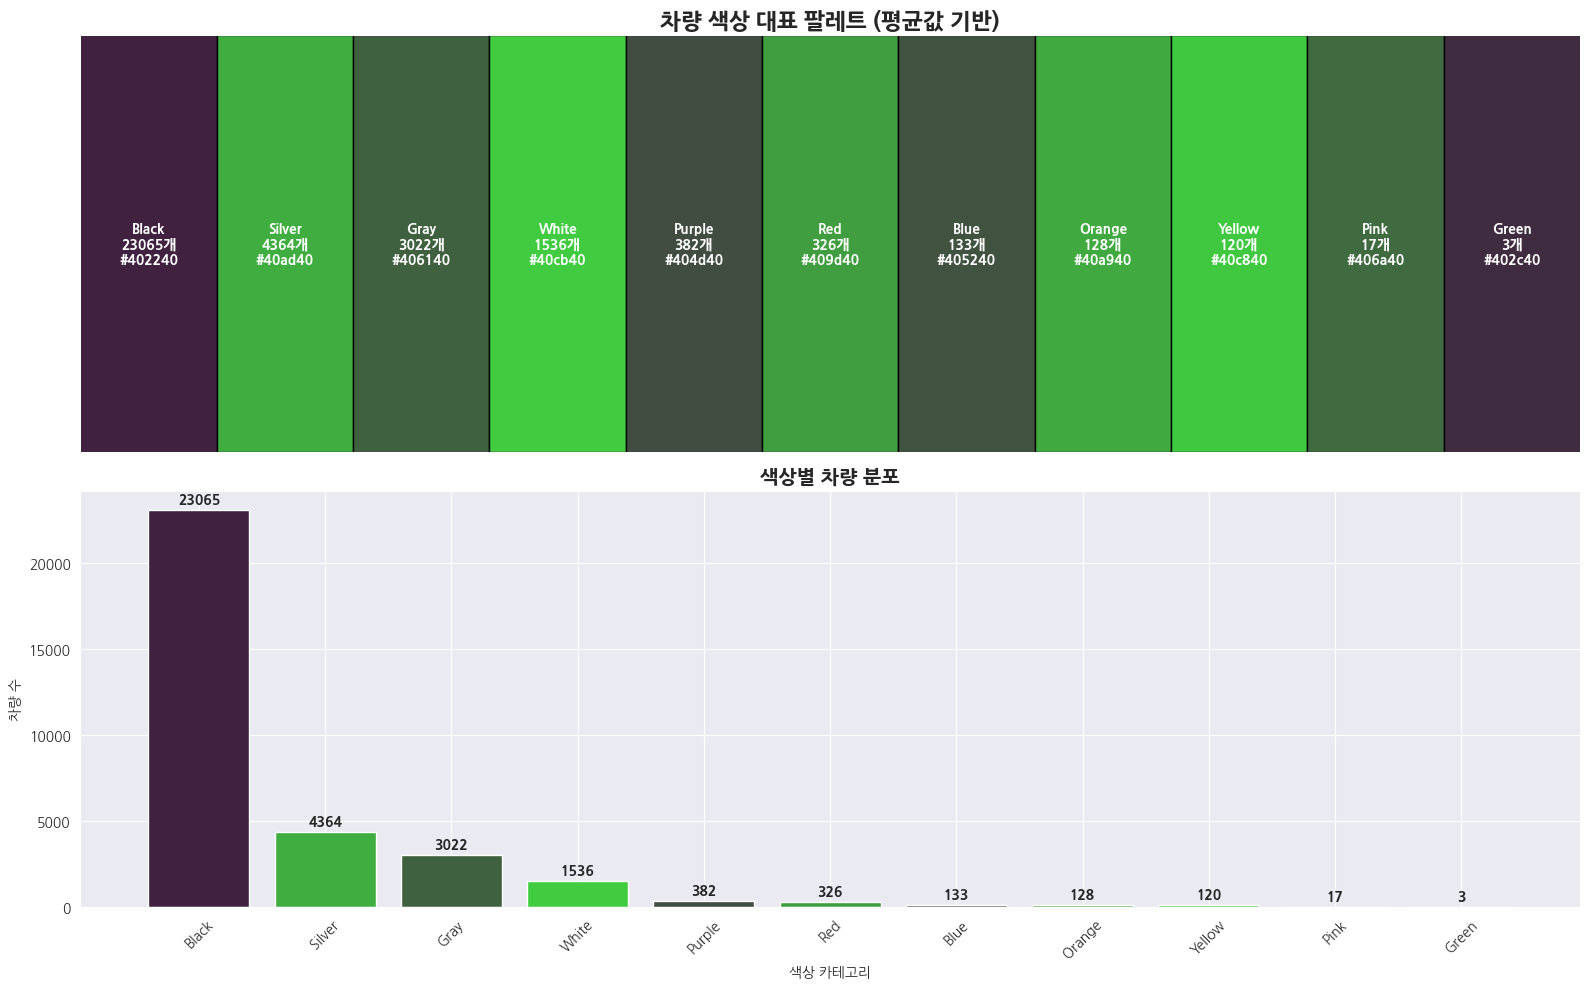

색상 팔레트 저장: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\representative_colors\representative_color_palette.png
결과 저장 완료:
  - 요약 테이블: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\representative_colors\representative_colors_summary.csv
  - 증강용 팔레트: C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\representative_colors\augmentation_color_palette.py

🎉 분석 완료!
총 11개 색상 카테고리 분석됨

=== 대표 색상 요약 ===
Black: 23065대 → #402240 (RGB(np.int64(64), np.int64(34), np.int64(64)))
Silver: 4364대 → #40ad40 (RGB(np.int64(64), np.int64(173), np.int64(64)))
Gray: 3022대 → #406140 (RGB(np.int64(64), np.int64(97), np.int64(64)))
White: 1536대 → #40cb40 (RGB(np.int64(64), np.int64(203), np.int64(64)))
Purple: 382대 → #404d40 (RGB(np.int64(64), np.int64(77), np.int64(64)))
Red: 326대 → #409d40 (RGB(np.int64(64), np.int64(157), np.int64(64)))
Blue: 133대 → #405240 (RGB(np.int64(64), np.int64(82), np.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
from collections import defaultdict
import re
from sklearn.cluster import DBSCAN
from scipy import stats
import os


def hex_to_rgb(hex_color):
    """HEX 색상을 RGB로 변환"""
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))


def rgb_to_hex(r, g, b):
    """RGB를 HEX로 변환"""
    return f"#{int(r):02x}{int(g):02x}{int(b):02x}"


def remove_outliers_iqr(data, multiplier=1.5):
    """IQR 방법으로 이상치 제거"""
    Q1 = np.percentile(data, 25, axis=0)
    Q3 = np.percentile(data, 75, axis=0)
    IQR = Q3 - Q1
    
    # 각 RGB 채널별로 이상치 마스크 생성
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    # 모든 채널이 정상 범위에 있는 데이터만 선택
    mask = np.all((data >= lower_bound) & (data <= upper_bound), axis=1)
    return data[mask]


def remove_outliers_zscore(data, threshold=2.5):
    """Z-score 방법으로 이상치 제거"""
    z_scores = np.abs(stats.zscore(data, axis=0))
    # 모든 채널의 z-score가 임계값 이하인 데이터만 선택
    mask = np.all(z_scores < threshold, axis=1)
    return data[mask]


def parse_rgb_string(rgb_str):
    """RGB 문자열을 튜플로 변환하는 함수"""
    try:
        # "(np.int64(124), np.int64(128), np.int64(138))" 형태에서 숫자 추출
        numbers = re.findall(r'(\d+)', str(rgb_str))
        if len(numbers) >= 3:
            return (int(numbers[0]), int(numbers[1]), int(numbers[2]))
        return None
    except Exception as e:
        print(f"RGB 파싱 오류: {rgb_str} -> {e}")
        return None


def analyze_color_representatives(csv_path):
    """색상 카테고리별 대표 색상 분석"""
    
    print("색상 분석 CSV 로드 중...")
    df = pd.read_csv(csv_path, encoding='utf-8')
    
    print(f"로드된 데이터: {len(df)}행")
    print(f"컬럼명: {list(df.columns)}")
    
    # RGB 값 파싱
    print("RGB 값 파싱 중...")
    rgb_values = []
    valid_indices = []
    
    for idx, rgb_str in enumerate(df['RGB']):
        rgb = parse_rgb_string(rgb_str)
        if rgb:
            rgb_values.append(rgb)
            valid_indices.append(idx)
        else:
            print(f"파싱 실패 {idx}: {rgb_str}")
    
    # 유효한 데이터만 필터링
    df_valid = df.iloc[valid_indices].copy()
    df_valid['rgb_tuple'] = rgb_values
    
    print(f"총 {len(df)}개 중 {len(df_valid)}개 유효한 데이터")
    
    # 색상 카테고리별 분석
    color_representatives = {}
    color_stats = {}
    
    print("\n색상 카테고리별 대표 색상 추출:")
    print("=" * 60)
    
    # 색상 범주별로 그룹화
    for color_category in df_valid['색상범주'].unique():
        color_data = df_valid[df_valid['색상범주'] == color_category]
        
        if len(color_data) < 3:  # 데이터가 너무 적으면 스킵
            print(f"\n{color_category}: 데이터 부족 (중 {len(color_data)}개) - 스킵")
            continue
        
        # RGB 값들을 numpy 배열로 변환
        rgb_array = np.array([rgb for rgb in color_data['rgb_tuple']])
        
        print(f"\n{color_category} ({len(color_data)}개)")
        print(f"  원본 RGB 범위: R({rgb_array[:,0].min()}-{rgb_array[:,0].max()}) "
              f"G({rgb_array[:,1].min()}-{rgb_array[:,1].max()}) "
              f"B({rgb_array[:,2].min()}-{rgb_array[:,2].max()})")
        
        # 방법 1: IQR로 이상치 제거
        rgb_clean_iqr = remove_outliers_iqr(rgb_array, multiplier=1.5)
        
        # 방법 2: Z-score로 이상치 제거
        rgb_clean_zscore = remove_outliers_zscore(rgb_array, threshold=2.0)
        
        # 더 많은 데이터를 보존하는 방법 선택
        if len(rgb_clean_iqr) >= len(rgb_clean_zscore):
            rgb_clean = rgb_clean_iqr
            method = "IQR"
        else:
            rgb_clean = rgb_clean_zscore
            method = "Z-score"
        
        if len(rgb_clean) == 0:
            rgb_clean = rgb_array  # 이상치 제거 실패 시 원본 사용
            method = "None"
        
        # 평균값 계산
        mean_rgb = np.mean(rgb_clean, axis=0).astype(int)
        median_rgb = np.median(rgb_clean, axis=0).astype(int)
        
        # 표준편차 계산
        std_rgb = np.std(rgb_clean, axis=0)
        
        representative_hex = rgb_to_hex(*mean_rgb)
        median_hex = rgb_to_hex(*median_rgb)
        
        print(f"  이상치 제거 ({method}): {len(rgb_array)} → {len(rgb_clean)}개")
        print(f"  평균 RGB: {tuple(mean_rgb)} → {representative_hex}")
        print(f"  중앙값 RGB: {tuple(median_rgb)} → {median_hex}")
        print(f"  표준편차: R({std_rgb[0]:.1f}) G({std_rgb[1]:.1f}) B({std_rgb[2]:.1f})")
        
        color_representatives[color_category] = {
            'count': len(color_data),
            'count_after_outlier_removal': len(rgb_clean),
            'outlier_removal_method': method,
            'mean_rgb': tuple(mean_rgb),
            'median_rgb': tuple(median_rgb),
            'mean_hex': representative_hex,
            'median_hex': median_hex,
            'std_rgb': tuple(std_rgb),
            'min_rgb': tuple(rgb_clean.min(axis=0)),
            'max_rgb': tuple(rgb_clean.max(axis=0))
        }
        
        color_stats[color_category] = {
            'original_data': rgb_array,
            'cleaned_data': rgb_clean
        }
    
    return color_representatives, color_stats


def create_color_palette_visualization(color_representatives, output_path):
    """대표 색상 팔레트 시각화"""
    
    # 색상 개수 순으로 정렬
    sorted_colors = sorted(color_representatives.items(), 
                          key=lambda x: x[1]['count'], 
                          reverse=True)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))
    
    # 1. 평균 기반 팔레트
    colors_mean = []
    labels_mean = []
    counts = []
    
    for color_name, info in sorted_colors:
        colors_mean.append(info['mean_hex'])
        labels_mean.append(f"{color_name}\n{info['count']}개\n{info['mean_hex']}")
        counts.append(info['count'])
    
    # 색상 사각형 그리기
    for i, (color, label, count) in enumerate(zip(colors_mean, labels_mean, counts)):
        rect = plt.Rectangle((i, 0), 1, 1, facecolor=color, edgecolor='black', linewidth=1)
        ax1.add_patch(rect)
        ax1.text(i + 0.5, 0.5, label, ha='center', va='center', 
                fontsize=10, fontweight='bold',
                color='white' if sum(hex_to_rgb(color)) < 400 else 'black')
    
    ax1.set_xlim(0, len(colors_mean))
    ax1.set_ylim(0, 1)
    ax1.set_title('차량 색상 대표 팔레트 (평균값 기반)', fontsize=16, fontweight='bold')
    ax1.set_xticks([])
    ax1.set_yticks([])
    
    # 2. 개수별 막대 그래프
    ax2.bar(range(len(counts)), counts, color=colors_mean)
    ax2.set_xlabel('색상 카테고리')
    ax2.set_ylabel('차량 수')
    ax2.set_title('색상별 차량 분포', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(len(labels_mean)))
    ax2.set_xticklabels([label.split('\n')[0] for label in labels_mean], rotation=45)
    
    # 막대 위에 숫자 표시
    for i, count in enumerate(counts):
        ax2.text(i, count + max(counts) * 0.01, str(count), 
                ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"색상 팔레트 저장: {output_path}")


def save_representative_colors(color_representatives, output_dir):
    """대표 색상 결과 저장"""
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. 요약 테이블
    summary_data = []
    for color_name, info in sorted(color_representatives.items(), 
                                  key=lambda x: x[1]['count'], 
                                  reverse=True):
        summary_data.append({
            '색상명': color_name,
            '차량수': info['count'],
            '이상치제거후': info['count_after_outlier_removal'],
            '제거방법': info['outlier_removal_method'],
            '평균_RGB': str(info['mean_rgb']),
            '평균_HEX': info['mean_hex'],
            '중앙값_RGB': str(info['median_rgb']),
            '중앙값_HEX': info['median_hex'],
            '표준편차_R': round(info['std_rgb'][0], 1),
            '표준편차_G': round(info['std_rgb'][1], 1),
            '표준편차_B': round(info['std_rgb'][2], 1)
        })
    
    summary_df = pd.DataFrame(summary_data)
    summary_path = os.path.join(output_dir, 'representative_colors_summary.csv')
    summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
    
    # 2. 증강용 색상 팔레트 (post_augmentation에서 사용할 수 있도록)
    augmentation_colors = {}
    for color_name, info in color_representatives.items():
        augmentation_colors[color_name.lower().replace(' ', '_')] = info['mean_rgb']
    
    # Python 딕셔너리 형태로 저장
    palette_path = os.path.join(output_dir, 'augmentation_color_palette.py')
    with open(palette_path, 'w', encoding='utf-8') as f:
        f.write("# 차량 색상 증강용 대표 색상 팔레트\n")
        f.write("# 실제 차량 데이터에서 추출된 대표 색상들\n\n")
        f.write("REPRESENTATIVE_CAR_COLORS = {\n")
        for color_name, rgb in augmentation_colors.items():
            original_key = next(k for k in color_representatives.keys() 
                              if k.lower().replace(' ', '_') == color_name)
            f.write(f"    '{color_name}': {list(rgb)},  # {color_representatives[original_key]['mean_hex']}\n")
        f.write("}\n")
    
    print(f"결과 저장 완료:")
    print(f"  - 요약 테이블: {summary_path}")
    print(f"  - 증강용 팔레트: {palette_path}")
    
    return augmentation_colors


def main():
    """메인 실행 함수"""
    
    # 파일 경로 (실제 데이터 경로에 맞게 수정하세요)
    CSV_PATH = r"C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\class_wise_color_details.csv"  # 실제 파일 경로로 수정
    OUTPUT_DIR = r"C:\Users\tjdwn\GitHub\Hecto-AI-Challenge-CarClassification\car_classification\analysis\representative_colors"
    
    print("🎨 차량 색상 대표값 분석 시작")
    print(f"입력 파일: {CSV_PATH}")
    print(f"출력 디렉토리: {OUTPUT_DIR}")
    print("=" * 60)
    
    # 1. 대표 색상 분석
    color_representatives, color_stats = analyze_color_representatives(CSV_PATH)
    
    # 2. 시각화
    palette_path = os.path.join(OUTPUT_DIR, 'representative_color_palette.png')
    create_color_palette_visualization(color_representatives, palette_path)
    
    # 3. 결과 저장
    augmentation_colors = save_representative_colors(color_representatives, OUTPUT_DIR)
    
    print(f"\n🎉 분석 완료!")
    print(f"총 {len(color_representatives)}개 색상 카테고리 분석됨")
    
    # 요약 출력
    print("\n=== 대표 색상 요약 ===")
    sorted_colors = sorted(color_representatives.items(), 
                          key=lambda x: x[1]['count'], 
                          reverse=True)
    
    for color_name, info in sorted_colors:
        print(f"{color_name}: {info['count']}대 → {info['mean_hex']} (RGB{info['mean_rgb']})")


if __name__ == "__main__":
    main()

## 증강 테스트